In [6]:
library(IlluminaHumanMethylation450kanno.ilmn12.hg19)

Loading required package: minfi

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading re

In [7]:
library(minfi)

In [2]:
metadata = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_pd.rds")
rownames(metadata) = metadata$Sample_Name

In [22]:
idat_dir = "/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/to_geo/methylation/"
rgSet <- read.metharray.exp(base = idat_dir)

In [27]:
MSet <- preprocessRaw(rgSet)

Loading required package: IlluminaHumanMethylation450kmanifest



In [28]:
RSet <- ratioConvert(MSet, what = "both", keepCN = TRUE)

In [33]:
GRset <- mapToGenome(RSet)

In [34]:
sex = getSex(GRset)

In [37]:
metadata$id = paste0(metadata$Slide,'_',metadata$Array)

In [38]:
rownames(metadata) = metadata$id


In [40]:
new_sex_pd = merge(metadata,sex, by=0)
new_sex_pd$Sex==new_sex_pd$predictedSex

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[31] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[46] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[61] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

In [41]:
consensus_table <- table(Reference = new_sex_pd$Sex, Prediction = new_sex_pd$predictedSex)

# Display the table
print(consensus_table)

         Prediction
Reference  F  M
        F 38  0
        M  0 34


In [3]:
library(ggplot2)

# Create the confusion matrix data
confusion_data <- data.frame(
  Prediction = rep(c("Female", "Male"), each = 2),
  Observation = c("Female", "Male", "Female", "Male"),
  Value = c(38, 0, 0, 34)
)

# Plot using ggplot2
png('SexPrediction.png',width=6,height=6, unit='in',res=300)
ggplot(confusion_data, aes(x = Prediction, y = Observation, fill = Value)) +
  geom_tile(color = "black") + # Add borders around tiles
  geom_text(aes(label = Value), color = "black", size = 6) + # Add text to tiles
  scale_fill_gradient(low = "white", high = "orange") + # Gradient color
  labs(x = "Prediction", y = "Observation") +
  theme_minimal() +
  theme(
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.position = "none" # Hide legend
  )
dev.off()

png 
  2

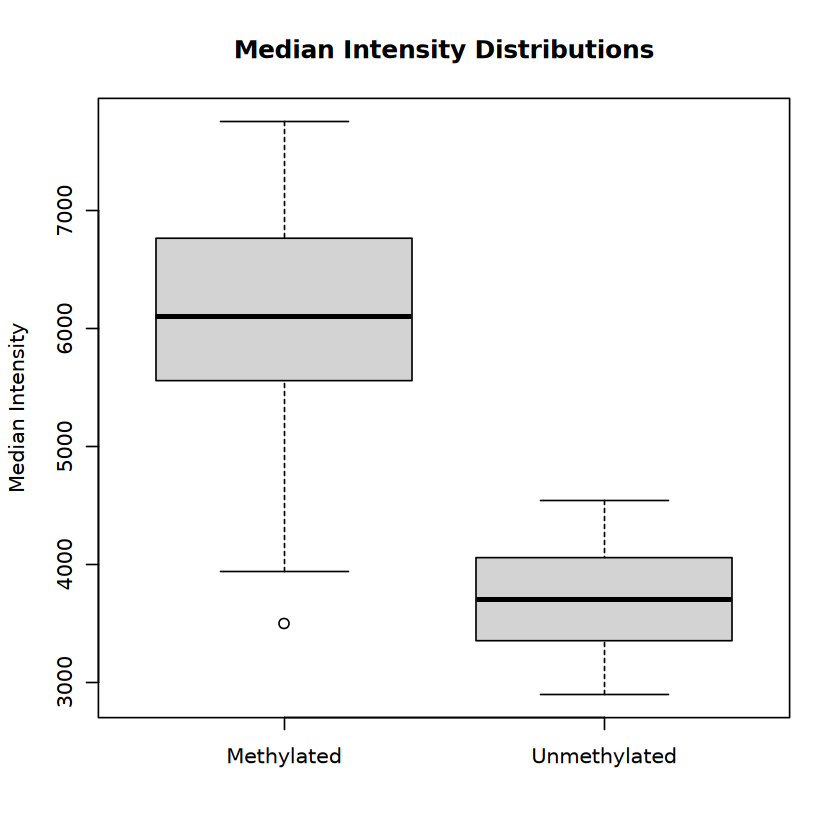

In [44]:
# Calculate median intensity for each channel
m_median <- apply(getMeth(MSet), 2, median, na.rm = TRUE)
u_median <- apply(getUnmeth(MSet), 2, median, na.rm = TRUE)

# Combine and inspect
intensity_medians <- data.frame(Sample = colnames(rgSet),
                                M_Median = m_median,
                                U_Median = u_median)
boxplot(m_median, u_median,
        names = c("Methylated", "Unmethylated"),
        main = "Median Intensity Distributions",
        ylab = "Median Intensity")

In [47]:
library(ggplot2)

In [54]:
intensity_medians$group = metadata[rownames(intensity_medians),]$Sample_Group

In [60]:
png('MedianIntensityScatter.png',width=7,height=6, unit='in',res=300)
ggplot(intensity_medians, aes(x = log2(M_Median), y = log2(U_Median),color=group)) +
  geom_point(size = 3) +  # Points for good and bad samples
  geom_abline(slope = -1, linetype = "dashed") +
  labs(
    title = "Median Intensity Scatterplot",
    x = "Meth median intensity (log2)",
    y = "Unmeth median intensity (log2)",
    color = "Sample Group"
  ) +
  theme_minimal() 
dev.off()

png 
  2